# Notebook 1: data validation, leakage-safe features, baselines

Project 4, retail demand forecasting on FreshRetailNet-50K (CC BY 4.0, Dingdong Inc., arXiv 2505.16319).
Target: daily `sale_amount` per store-product series. Forecast: 7 days ahead from a fixed origin.

This notebook:
1. Downloads the dataset at a pinned Hugging Face revision and verifies SHA-256 checksums.
2. Validates structure: row counts, nulls, panel completeness, date contiguity, static attributes.
3. Verifies the meaning of the hourly and stockout columns against each other.
4. Profiles demand (weekday, stockout, holiday, promotion, discount effects).
5. Defines the time-based split and writes the leakage-safe feature and evaluation modules.
6. Runs leakage tests: synthetic unit tests, then invariance tests on the real validation horizon.
7. Scores three baselines on the validation horizon with WAPE, WPE, MAE, RMSE and error breakdowns.

Not in this notebook: model training (notebook 2) and any scoring on the official eval split.
The eval split is loaded only for structural checks; its targets are not used for any metric here.

Runtime: CPU only, no GPU needed. Kaggle setting required: Internet on.

## 1. Configuration

In [1]:
import hashlib
import json
import platform
import shutil
import subprocess
import sys
import time
import urllib.request
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.compute as pc
import pyarrow.parquet as pq

DATASET_REPO = "Dingdong-Inc/FreshRetailNet-50K"
DATASET_REVISION = "08c1fab7f9257bc73679d415d65d644165d351d4"
DATASET_FILES = {
    "train": ("data/train.parquet", "6706832db892bbae4969c19d87e07975d2543d2ba7d7d4756360654785de5a3d"),
    "eval": ("data/eval.parquet", "1b118840664280c6b88bffc84c80ee1f54c05d911e354b7599e5da10995e960e"),
}
CACHE_DIR = Path.home() / ".cache" / "freshretailnet-50k" / DATASET_REVISION
KAGGLE_WORKING = Path("/kaggle/working")
OUTPUT_DIR = KAGGLE_WORKING if KAGGLE_WORKING.exists() else Path.cwd() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODULE_DIR = Path.cwd()
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

EXPECTED_TRAIN_ROWS = 4_500_000
EXPECTED_EVAL_ROWS = 350_000
EXPECTED_SERIES = 50_000
HORIZON_DAYS = 7
SEED = 20240626
LIST_COLS = ["hours_sale", "hours_stock_status"]

environment = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "pyarrow": pa.__version__,
    "matplotlib": matplotlib.__version__,
    "on_kaggle": KAGGLE_WORKING.exists(),
}
print(json.dumps(environment, indent=2))
print("output dir:", OUTPUT_DIR)

{
  "python": "3.11.15",
  "platform": "Linux-6.18.44-fc-v33-x86_64-with-glibc2.39",
  "numpy": "2.4.4",
  "pandas": "3.0.2",
  "pyarrow": "25.0.1",
  "matplotlib": "3.10.9",
  "on_kaggle": false
}
output dir: /home/claude/p4/run_final_pd3/outputs


## 2. Download at a pinned revision

The revision hash fixes the dataset version; the SHA-256 check fails the notebook if the bytes differ.

In [2]:
def sha256_of(path, chunk=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as fh:
        for block in iter(lambda: fh.read(chunk), b""):
            h.update(block)
    return h.hexdigest()


def fetch(split):
    rel, expected = DATASET_FILES[split]
    dest = CACHE_DIR / rel
    if not (dest.exists() and sha256_of(dest) == expected):
        dest.parent.mkdir(parents=True, exist_ok=True)
        url = f"https://huggingface.co/datasets/{DATASET_REPO}/resolve/{DATASET_REVISION}/{rel}"
        tmp = dest.with_suffix(".part")
        with urllib.request.urlopen(url, timeout=120) as resp, open(tmp, "wb") as out:
            shutil.copyfileobj(resp, out, 1 << 20)
        tmp.replace(dest)
    actual = sha256_of(dest)
    assert actual == expected, f"{split}: sha256 mismatch {actual}"
    print(f"{split}: {dest} {dest.stat().st_size:,} bytes, sha256 ok")
    return dest


t0 = time.time()
TRAIN_PATH = fetch("train")
EVAL_PATH = fetch("eval")
print(f"{time.time() - t0:.1f}s")

train: /root/.cache/freshretailnet-50k/08c1fab7f9257bc73679d415d65d644165d351d4/data/train.parquet 106,436,287 bytes, sha256 ok


eval: /root/.cache/freshretailnet-50k/08c1fab7f9257bc73679d415d65d644165d351d4/data/eval.parquet 8,440,124 bytes, sha256 ok
6.1s


## 3. Load and validate structure

In [3]:
profile = {"dataset": {"repo": DATASET_REPO, "revision": DATASET_REVISION}}


def check(name, condition, detail=None):
    profile.setdefault("checks", {})[name] = {"passed": bool(condition), "detail": detail}
    print(("PASS " if condition else "FAIL ") + name + ("" if detail is None else f" | {detail}"))
    assert condition, name


train_schema = pq.read_schema(TRAIN_PATH)
eval_schema = pq.read_schema(EVAL_PATH)
check("train and eval schemas identical", train_schema.equals(eval_schema, check_metadata=False))
scalar_cols = [c for c in train_schema.names if c not in LIST_COLS]

train = pd.read_parquet(TRAIN_PATH, columns=scalar_cols)
evald = pd.read_parquet(EVAL_PATH, columns=scalar_cols)
check("train row count", len(train) == EXPECTED_TRAIN_ROWS, len(train))
check("eval row count", len(evald) == EXPECTED_EVAL_ROWS, len(evald))
check("no nulls in train scalar columns", int(train.isna().sum().sum()) == 0)
check("no nulls in eval scalar columns (including eval sale_amount)", int(evald.isna().sum().sum()) == 0)

key = ["store_id", "product_id"]
for name, frame in (("train", train), ("eval", evald)):
    check(f"{name}: no duplicate (store, product, dt)", not frame.duplicated(key + ["dt"]).any())

train_series = train[key].drop_duplicates()
eval_series = evald[key].drop_duplicates()
check("series count train", len(train_series) == EXPECTED_SERIES, len(train_series))
check("same series set in train and eval",
      len(train_series.merge(eval_series, on=key, how="inner")) == EXPECTED_SERIES)

train_dates = pd.DatetimeIndex(sorted(pd.to_datetime(train["dt"].unique())))
eval_dates = pd.DatetimeIndex(sorted(pd.to_datetime(evald["dt"].unique())))
check("train dates contiguous", train_dates.equals(pd.date_range(train_dates[0], train_dates[-1], freq="D")),
      f"{train_dates[0].date()}..{train_dates[-1].date()} ({len(train_dates)} days)")
check("eval dates contiguous", eval_dates.equals(pd.date_range(eval_dates[0], eval_dates[-1], freq="D")),
      f"{eval_dates[0].date()}..{eval_dates[-1].date()} ({len(eval_dates)} days)")
check("eval horizon equals forecast horizon", len(eval_dates) == HORIZON_DAYS)
check("eval starts the day after train ends", eval_dates[0] == train_dates[-1] + pd.Timedelta(days=1))
check("complete train panel", (train.groupby(key).size() == len(train_dates)).all())
check("complete eval panel", (evald.groupby(key).size() == len(eval_dates)).all())

both = pd.concat([train, evald], ignore_index=True)
static_cols = ["city_id", "management_group_id", "first_category_id", "second_category_id", "third_category_id"]
check("static attributes constant per series",
      int(both.groupby(key)[static_cols].nunique().max().max()) == 1)
check("city constant per store", int(both.groupby("store_id")["city_id"].nunique().max()) == 1)
check("category and management group constant per product",
      int(both.groupby("product_id")[["third_category_id", "management_group_id"]].nunique().max().max()) == 1)
check("holiday_flag constant per date", int(both.groupby("dt")["holiday_flag"].nunique().max()) == 1)
check("weather constant per store and date",
      int(both.groupby(["store_id", "dt"])[["precpt", "avg_temperature"]].nunique().max().max()) == 1)
check("sale_amount non-negative", bool((both["sale_amount"] >= 0).all()))
check("stock_hour6_22_cnt within 0..16", bool(both["stock_hour6_22_cnt"].between(0, 16).all()))
check("activity_flag and holiday_flag binary",
      set(both["activity_flag"].unique()) <= {0, 1} and set(both["holiday_flag"].unique()) <= {0, 1})

profile["shape"] = {
    "train_rows": len(train), "eval_rows": len(evald), "series": len(train_series),
    "stores": int(both["store_id"].nunique()), "products": int(both["product_id"].nunique()),
    "cities": int(both["city_id"].nunique()),
    "train_dates": [str(train_dates[0].date()), str(train_dates[-1].date())],
    "eval_dates": [str(eval_dates[0].date()), str(eval_dates[-1].date())],
}
print(json.dumps(profile["shape"], indent=2))
del both

PASS train and eval schemas identical


PASS train row count | 4500000
PASS eval row count | 350000
PASS no nulls in train scalar columns
PASS no nulls in eval scalar columns (including eval sale_amount)


PASS train: no duplicate (store, product, dt)
PASS eval: no duplicate (store, product, dt)


PASS series count train | 50000
PASS same series set in train and eval
PASS train dates contiguous | 2024-03-28..2024-06-25 (90 days)
PASS eval dates contiguous | 2024-06-26..2024-07-02 (7 days)
PASS eval horizon equals forecast horizon
PASS eval starts the day after train ends


PASS complete train panel
PASS complete eval panel


PASS static attributes constant per series
PASS city constant per store


PASS category and management group constant per product


PASS holiday_flag constant per date


PASS weather constant per store and date
PASS sale_amount non-negative
PASS stock_hour6_22_cnt within 0..16
PASS activity_flag and holiday_flag binary
{
  "train_rows": 4500000,
  "eval_rows": 350000,
  "series": 50000,
  "stores": 898,
  "products": 865,
  "cities": 18,
  "train_dates": [
    "2024-03-28",
    "2024-06-25"
  ],
  "eval_dates": [
    "2024-06-26",
    "2024-07-02"
  ]
}


## 4. Hourly and stockout column semantics

Checked over every training row, in batches to bound memory:
- `sale_amount` equals the sum of the 24 values in `hours_sale`.
- `stock_hour6_22_cnt` equals the number of 1s in `hours_stock_status` for hours 6..21 (16 hours).
- Hours with status 1 have lower sales than hours with status 0, which identifies 1 as out of stock.

In [4]:
rows = 0
sum_mismatch = 0
count_mismatch = 0
bad_lengths = 0
status_values = set()
sales_by_status = np.zeros(2)
hours_by_status = np.zeros(2)
pf = pq.ParquetFile(TRAIN_PATH)
for batch in pf.iter_batches(batch_size=500_000, columns=["sale_amount", "stock_hour6_22_cnt"] + LIST_COLS):
    lengths_ok = all(
        pc.min_max(pc.list_value_length(batch.column(c))).as_py() == {"min": 24, "max": 24} for c in LIST_COLS
    )
    bad_lengths += 0 if lengths_ok else 1
    hs = batch.column("hours_sale").flatten().to_numpy(zero_copy_only=False).reshape(-1, 24)
    st = batch.column("hours_stock_status").flatten().to_numpy(zero_copy_only=False).reshape(-1, 24)
    sa = batch.column("sale_amount").to_numpy()
    cnt = batch.column("stock_hour6_22_cnt").to_numpy()
    sum_mismatch += int((~np.isclose(hs.sum(axis=1), sa, atol=1e-6)).sum())
    count_mismatch += int((st[:, 6:22].sum(axis=1) != cnt).sum())
    status_values |= set(np.unique(st).tolist())
    for s in (0, 1):
        mask = st == s
        sales_by_status[s] += hs[mask].sum()
        hours_by_status[s] += mask.sum()
    rows += len(sa)
    del hs, st

mean_hourly = sales_by_status / hours_by_status
check("all hourly lists have 24 values", bad_lengths == 0)
check("sale_amount equals sum of hours_sale", sum_mismatch == 0, f"{sum_mismatch} mismatches in {rows:,} rows")
check("stock_hour6_22_cnt equals stockout hours 6..21", count_mismatch == 0, f"{count_mismatch} mismatches")
check("stock status values are 0/1", status_values <= {0, 1}, sorted(status_values))
check("status 1 hours sell less than status 0 hours", mean_hourly[1] < mean_hourly[0],
      f"mean hourly sales status0={mean_hourly[0]:.4f} status1={mean_hourly[1]:.4f}")
profile["hourly_semantics"] = {"rows_checked": rows, "mean_hourly_sales_in_stock": float(mean_hourly[0]),
                               "mean_hourly_sales_out_of_stock": float(mean_hourly[1])}

PASS all hourly lists have 24 values
PASS sale_amount equals sum of hours_sale | 0 mismatches in 4,500,000 rows
PASS stock_hour6_22_cnt equals stockout hours 6..21 | 0 mismatches
PASS stock status values are 0/1 | [0, 1]
PASS status 1 hours sell less than status 0 hours | mean hourly sales status0=0.0540 status1=0.0042


## 5. Demand profile (training period only)

In [5]:
tr = train.assign(date=pd.to_datetime(train["dt"]))
eda = {
    "zero_sales_share": float((tr["sale_amount"] == 0).mean()),
    "rows_with_any_stockout_hour_share": float((tr["stock_hour6_22_cnt"] > 0).mean()),
    "rows_full_day_stockout_share": float((tr["stock_hour6_22_cnt"] == 16).mean()),
    "activity_flag_share": float(tr["activity_flag"].mean()),
    "holiday_date_count": int(tr.groupby("dt")["holiday_flag"].first().sum()),
    "mean_sales_by_day_of_week": tr.groupby(tr["date"].dt.dayofweek)["sale_amount"].mean().round(4).to_dict(),
    "mean_sales_by_holiday_flag": tr.groupby("holiday_flag")["sale_amount"].mean().round(4).to_dict(),
    "mean_sales_by_activity_flag": tr.groupby("activity_flag")["sale_amount"].mean().round(4).to_dict(),
    "mean_sales_by_stockout_hours": tr.groupby("stock_hour6_22_cnt")["sale_amount"].mean().round(4).to_dict(),
    "sale_amount_quantiles": tr["sale_amount"].quantile([0.5, 0.9, 0.99, 1.0]).round(3).to_dict(),
}
disc_bins = pd.cut(tr["discount"], [-0.001, 0.5, 0.7, 0.9, 0.99, 1.0, np.inf],
                   labels=["<=0.5", "0.5-0.7", "0.7-0.9", "0.9-0.99", "0.99-1.0", ">1.0"])
eda["mean_sales_by_discount_bin"] = tr.groupby(disc_bins, observed=True)["sale_amount"].mean().round(4).to_dict()
eda["rows_by_discount_bin"] = disc_bins.value_counts(sort=False).to_dict()
profile["eda"] = eda
for k, v in eda.items():
    print(f"{k}: {v}")

zero_sales_share: 0.04461333333333333
rows_with_any_stockout_hour_share: 0.442668
rows_full_day_stockout_share: 0.040398
activity_flag_share: 0.3784206666666667
holiday_date_count: 31
mean_sales_by_day_of_week: {0: 0.9426, 1: 0.962, 2: 0.9069, 3: 0.866, 4: 0.9268, 5: 1.1781, 6: 1.2007}
mean_sales_by_holiday_flag: {0: 0.914, 1: 1.1596}
mean_sales_by_activity_flag: {0: 0.9897, 1: 1.0133}
mean_sales_by_stockout_hours: {0: 0.9745, 1: 1.3503, 2: 1.4827, 3: 1.4307, 4: 1.3396, 5: 1.2431, 6: 1.1512, 7: 1.085, 8: 1.0381, 9: 0.9599, 10: 0.8806, 11: 0.7693, 12: 0.6559, 13: 0.5919, 14: 0.4624, 15: 0.3286, 16: 0.046}
sale_amount_quantiles: {0.5: 0.7, 0.9: 2.0, 0.99: 5.8, 1.0: 44.9}
mean_sales_by_discount_bin: {'<=0.5': 7.0687, '0.5-0.7': 1.354, '0.7-0.9': 0.9978, '0.9-0.99': 0.9388, '0.99-1.0': 0.8647, '>1.0': 0.6353}
rows_by_discount_bin: {'<=0.5': 39631, '0.5-0.7': 279313, '0.7-0.9': 1290477, '0.9-0.99': 650049, '0.99-1.0': 2240496, '>1.0': 34}


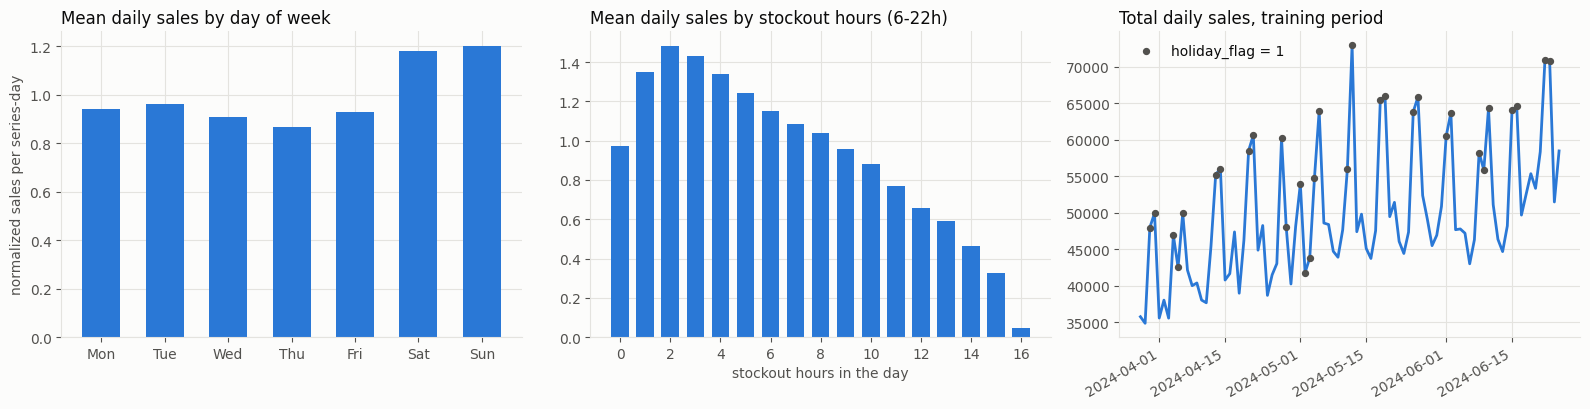

In [6]:
SURFACE, INK, INK_2, GRID, SERIES = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df", "#2a78d6"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": GRID,
    "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2, "text.color": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

dow = tr.groupby(tr["date"].dt.dayofweek)["sale_amount"].mean()
axes[0].bar(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], dow.values, color=SERIES, width=0.6)
axes[0].set_title("Mean daily sales by day of week", loc="left")
axes[0].set_ylabel("normalized sales per series-day")

soh = tr.groupby("stock_hour6_22_cnt")["sale_amount"].mean()
axes[1].bar(soh.index, soh.values, color=SERIES, width=0.7)
axes[1].set_title("Mean daily sales by stockout hours (6-22h)", loc="left")
axes[1].set_xlabel("stockout hours in the day")
axes[1].set_xticks(range(0, 17, 2))

daily = tr.groupby("date").agg(total=("sale_amount", "sum"), holiday=("holiday_flag", "first"))
axes[2].plot(daily.index, daily["total"], color=SERIES, linewidth=2)
hol = daily[daily["holiday"] == 1]
axes[2].scatter(hol.index, hol["total"], s=18, color=INK_2, zorder=3, label="holiday_flag = 1")
axes[2].set_title("Total daily sales, training period", loc="left")
axes[2].legend(frameon=False, loc="upper left")
plt.setp(axes[2].get_xticklabels(), rotation=30, ha="right")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "nb1_demand_profile.png", dpi=130)
plt.show()

Reading the stockout panel: rows with 1 to 4 stockout hours have higher mean sales than rows with none, because
fast-selling items are the ones that run out. Sales only fall as stockout hours grow toward a full day. Stockout
hours therefore carry both a demand signal and a censoring signal, which is why they enter the model only as lagged
history and never for the target day.

## 6. Which same-day columns are known in advance

| Column | Treated as | Basis |
|---|---|---|
| `holiday_flag` | known in advance | constant per date across all stores (checked above); calendar |
| `activity_flag` | known in advance | planned promotion; same assumption as the dataset paper |
| `discount` | known in advance, **unverified** | see evidence below |
| `stock_hour6_22_cnt`, `hours_stock_status` | realized, never a same-day feature | stock state is only observed after the day |
| weather columns | realized, excluded by default | actual weather, not a forecast; available only in the labelled `oracle` mode |
| `sale_amount`, `hours_sale` | target | |

If `discount` were computed from transactions (price paid over list price), it would carry same-day information.
The cell below prints the evidence available in the data. The known-in-advance treatment follows the dataset paper,
and a with/without same-day discount comparison belongs in notebook 2.

In [7]:
zero_day = train["sale_amount"] == 0
full_stockout = train["stock_hour6_22_cnt"] == 16
discount_evidence = {
    "share_discount_eq_1_on_zero_sale_days": float((train.loc[zero_day, "discount"] == 1).mean()),
    "share_discount_eq_1_on_positive_sale_days": float((train.loc[~zero_day, "discount"] == 1).mean()),
    "share_discount_eq_1_on_full_stockout_days": float((train.loc[full_stockout, "discount"] == 1).mean()),
    "rows_discount_eq_0": int((train["discount"] == 0).sum()),
    "rows_discount_gt_1": int((train["discount"] > 1).sum()),
    "distinct_discount_values_per_series_median": float(train.groupby(key)["discount"].nunique().median()),
}
hol_by_date = pd.concat([train, evald]).groupby("dt")["holiday_flag"].first()
hol_by_date.index = pd.to_datetime(hol_by_date.index)
calendar_evidence = {
    "weekday_dates_flagged_holiday": [str(d.date()) for d in hol_by_date[(hol_by_date == 1) & (hol_by_date.index.dayofweek < 5)].index],
    "weekend_dates_not_flagged": [str(d.date()) for d in hol_by_date[(hol_by_date == 0) & (hol_by_date.index.dayofweek >= 5)].index],
}
profile["discount_evidence"] = discount_evidence
profile["calendar_evidence"] = calendar_evidence
print(json.dumps(discount_evidence, indent=2))
print(json.dumps(calendar_evidence, indent=2))

{
  "share_discount_eq_1_on_zero_sale_days": 0.6570382546323968,
  "share_discount_eq_1_on_positive_sale_days": 0.4766456396944576,
  "share_discount_eq_1_on_full_stockout_days": 0.6442838204311545,
  "rows_discount_eq_0": 16039,
  "rows_discount_gt_1": 34,
  "distinct_discount_values_per_series_median": 15.0
}
{
  "weekday_dates_flagged_holiday": [
    "2024-04-04",
    "2024-04-05",
    "2024-05-01",
    "2024-05-02",
    "2024-05-03",
    "2024-06-10"
  ],
  "weekend_dates_not_flagged": [
    "2024-04-07"
  ]
}


## 7. Time-based split

Random splits put later days into training and earlier days into testing, which lets the model learn from the
future it is scored on. All splits here are by date:

| Window | Dates | Use |
|---|---|---|
| fit | first 83 training days | feature history and model fitting |
| validation | last 7 training days | model selection and baseline comparison (this notebook) |
| eval | official 7-day eval split | scored once, at the end, for the final report |

Forecasts are made from a fixed origin (the last day before the 7-day window) for all 7 days at once.

In [8]:
VALIDATION_START = train_dates[-HORIZON_DAYS]
VALIDATION_ORIGIN = VALIDATION_START - pd.Timedelta(days=1)
split = {
    "fit": [str(train_dates[0].date()), str(VALIDATION_ORIGIN.date())],
    "validation": [str(VALIDATION_START.date()), str(train_dates[-1].date())],
    "eval": [str(eval_dates[0].date()), str(eval_dates[-1].date())],
    "horizon_days": HORIZON_DAYS,
}
profile["split"] = split
print(json.dumps(split, indent=2))

{
  "fit": [
    "2024-03-28",
    "2024-06-18"
  ],
  "validation": [
    "2024-06-19",
    "2024-06-25"
  ],
  "eval": [
    "2024-06-26",
    "2024-07-02"
  ],
  "horizon_days": 7
}


## 8. Feature and evaluation modules

Written as files so notebook 2 and the serving container import the same code (no train/serve drift).

Feature rule: every history feature for target day `t` reads only days `<= t - 7`. With a 7-day horizon, one feature
definition is valid for every horizon step from a single origin (direct strategy, no recursive feeding of
predictions). Cost: the nearest horizon days do not use the most recent 6 days of history.

In [9]:
%%writefile demand_features.py
"""Leakage-safe daily demand features for FreshRetailNet-50K.

Every history-derived feature for target day t reads only days <= t - MIN_LAG.
With MIN_LAG equal to the forecast horizon, one feature definition serves every
horizon step 1..HORIZON from a single forecast origin (direct strategy), and the
same code path is used for training rows and for serving requests.

Same-day columns are split into two groups:
- KNOWN_FUTURE_COLS: planned in advance (calendar, discount, promo activity).
  Treated as known for the target day. Discount is an assumption, see notebook 1.
- Realized same-day columns (target, stockout hours, weather): never used for
  the target day. Weather is only available through the explicit "oracle" mode,
  which exists for a labelled sensitivity comparison and not for serving.
"""
from __future__ import annotations

import numpy as np
import pandas as pd

KEY_COLS = ["store_id", "product_id"]
DATE_COL = "dt"
TARGET_COL = "sale_amount"
STOCK_COL = "stock_hour6_22_cnt"
STATIC_COLS = [
    "city_id",
    "store_id",
    "management_group_id",
    "first_category_id",
    "second_category_id",
    "third_category_id",
    "product_id",
]
KNOWN_FUTURE_COLS = ["discount", "activity_flag", "holiday_flag"]
WEATHER_COLS = ["precpt", "avg_temperature", "avg_humidity", "avg_wind_level"]
REALIZED_COLS = [TARGET_COL, STOCK_COL] + WEATHER_COLS

HORIZON = 7
MIN_LAG = HORIZON
SALES_LAGS = (7, 8, 9, 10, 11, 12, 13, 14, 21, 28)
SALES_MEAN_WINDOWS = (7, 14, 28)
SALES_STD_WINDOWS = (7, 28)
STOCK_MEAN_WINDOWS = (7, 28)
FULL_DAY_STOCKOUT_HOURS = 16
WEATHER_MODES = ("none", "oracle")

REQUIRED_HISTORY_DAYS = max(max(SALES_LAGS), MIN_LAG + max(SALES_MEAN_WINDOWS) - 1)


class PanelError(ValueError):
    pass


def to_panel(df: pd.DataFrame, value_cols: list[str]) -> tuple[pd.DataFrame, pd.DatetimeIndex, dict[str, np.ndarray]]:
    """Reshape a long frame into (n_series, n_days) arrays.

    Requires a complete, duplicate-free panel over a contiguous daily range.
    """
    missing = [c for c in KEY_COLS + [DATE_COL] + value_cols if c not in df.columns]
    if missing:
        raise PanelError(f"missing columns: {missing}")
    dates = pd.to_datetime(df[DATE_COL])
    start, end = dates.min(), dates.max()
    grid = pd.date_range(start, end, freq="D")
    n_days = len(grid)
    keys = df[KEY_COLS].drop_duplicates().sort_values(KEY_COLS).reset_index(drop=True)
    n_series = len(keys)
    if len(df) != n_series * n_days:
        raise PanelError(
            f"incomplete or duplicated panel: {len(df)} rows, expected {n_series} x {n_days} = {n_series * n_days}"
        )
    order = np.lexsort((dates.to_numpy(), df["product_id"].to_numpy(), df["store_id"].to_numpy()))
    sorted_dates = dates.to_numpy()[order].reshape(n_series, n_days)
    if not (sorted_dates == grid.to_numpy()[None, :]).all():
        raise PanelError("panel dates are not a complete contiguous grid for every series")
    sorted_keys = df[KEY_COLS].to_numpy()[order].reshape(n_series, n_days, len(KEY_COLS))
    if not (sorted_keys == sorted_keys[:, :1, :]).all():
        raise PanelError("series keys are not constant along the date axis after sorting")
    arrays = {c: df[c].to_numpy(dtype=np.float64)[order].reshape(n_series, n_days) for c in value_cols}
    return keys, grid, arrays


def lag(x: np.ndarray, k: int) -> np.ndarray:
    out = np.full_like(x, np.nan, dtype=np.float64)
    if k < x.shape[1]:
        out[:, k:] = x[:, : x.shape[1] - k]
    return out


def _window_sums(x: np.ndarray, window: int, offset: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Sums over days (t - offset - window + 1 .. t - offset), accumulated window element by element.

    Each output value depends only on the values inside its own window, so the result is bit-identical
    regardless of how much history precedes the window (required for serving parity).
    """
    s1 = np.zeros(x.shape, dtype=np.float64)
    s2 = np.zeros(x.shape, dtype=np.float64)
    n = np.zeros(x.shape, dtype=np.int32)
    for j in range(window):
        v = lag(x, offset + j)
        valid = ~np.isnan(v)
        v0 = np.where(valid, v, 0.0)
        s1 += v0
        s2 += v0 * v0
        n += valid
    return s1, s2, n


def rolling_mean(x: np.ndarray, window: int, offset: int) -> np.ndarray:
    """Mean over days (t - offset - window + 1 .. t - offset). NaN unless the full window is observed."""
    s1, _, n = _window_sums(x, window, offset)
    return np.where(n == window, s1 / window, np.nan)


def rolling_std(x: np.ndarray, window: int, offset: int) -> np.ndarray:
    """Population standard deviation over the same window as rolling_mean."""
    s1, s2, n = _window_sums(x, window, offset)
    mean = s1 / window
    var = np.maximum(s2 / window - mean * mean, 0.0)
    return np.where(n == window, np.sqrt(var), np.nan)


def feature_columns(weather_mode: str = "none") -> list[str]:
    if weather_mode not in WEATHER_MODES:
        raise ValueError(f"weather_mode must be one of {WEATHER_MODES}")
    cols = list(STATIC_COLS) + ["day_of_week"] + list(KNOWN_FUTURE_COLS)
    cols += [f"sales_lag_{k}" for k in SALES_LAGS]
    cols += [f"sales_mean_{w}_off{MIN_LAG}" for w in SALES_MEAN_WINDOWS]
    cols += [f"sales_std_{w}_off{MIN_LAG}" for w in SALES_STD_WINDOWS]
    cols += ["sales_same_dow_mean_4w", f"sales_zero_share_28_off{MIN_LAG}"]
    cols += [f"stock_hours_lag_{MIN_LAG}"]
    cols += [f"stock_hours_mean_{w}_off{MIN_LAG}" for w in STOCK_MEAN_WINDOWS]
    cols += [f"stock_fullday_share_28_off{MIN_LAG}"]
    cols += [f"discount_mean_7_off{MIN_LAG}", "discount_vs_recent", f"activity_share_28_off{MIN_LAG}"]
    if weather_mode == "oracle":
        cols += [f"oracle_{c}" for c in WEATHER_COLS]
    return cols


def build_feature_arrays(
    arrays: dict[str, np.ndarray],
    grid: pd.DatetimeIndex,
    weather_mode: str = "none",
) -> dict[str, np.ndarray]:
    """History and known-future features as (n_series, n_days) arrays. Static columns excluded."""
    if weather_mode not in WEATHER_MODES:
        raise ValueError(f"weather_mode must be one of {WEATHER_MODES}")
    y = arrays[TARGET_COL]
    stock = arrays[STOCK_COL]
    n_series, n_days = y.shape
    f: dict[str, np.ndarray] = {}

    f["day_of_week"] = np.broadcast_to(grid.dayofweek.to_numpy(dtype=np.float64)[None, :], (n_series, n_days))
    for c in KNOWN_FUTURE_COLS:
        f[c] = arrays[c]

    for k in SALES_LAGS:
        f[f"sales_lag_{k}"] = lag(y, k)
    for w in SALES_MEAN_WINDOWS:
        f[f"sales_mean_{w}_off{MIN_LAG}"] = rolling_mean(y, w, MIN_LAG)
    for w in SALES_STD_WINDOWS:
        f[f"sales_std_{w}_off{MIN_LAG}"] = rolling_std(y, w, MIN_LAG)
    f["sales_same_dow_mean_4w"] = (lag(y, 7) + lag(y, 14) + lag(y, 21) + lag(y, 28)) / 4.0
    zero = np.where(np.isnan(y), np.nan, (y == 0).astype(np.float64))
    f[f"sales_zero_share_28_off{MIN_LAG}"] = rolling_mean(zero, 28, MIN_LAG)

    f[f"stock_hours_lag_{MIN_LAG}"] = lag(stock, MIN_LAG)
    for w in STOCK_MEAN_WINDOWS:
        f[f"stock_hours_mean_{w}_off{MIN_LAG}"] = rolling_mean(stock, w, MIN_LAG)
    fullday = np.where(np.isnan(stock), np.nan, (stock >= FULL_DAY_STOCKOUT_HOURS).astype(np.float64))
    f[f"stock_fullday_share_28_off{MIN_LAG}"] = rolling_mean(fullday, 28, MIN_LAG)

    disc_recent = rolling_mean(arrays["discount"], 7, MIN_LAG)
    f[f"discount_mean_7_off{MIN_LAG}"] = disc_recent
    f["discount_vs_recent"] = arrays["discount"] - disc_recent
    f[f"activity_share_28_off{MIN_LAG}"] = rolling_mean(arrays["activity_flag"], 28, MIN_LAG)

    if weather_mode == "oracle":
        for c in WEATHER_COLS:
            f[f"oracle_{c}"] = arrays[c]
    return f


def mask_realized(arrays: dict[str, np.ndarray], grid: pd.DatetimeIndex, first_masked_date) -> dict[str, np.ndarray]:
    """Copy of arrays with realized columns set to NaN from first_masked_date onward."""
    idx = int(np.searchsorted(grid.to_numpy(), np.datetime64(pd.Timestamp(first_masked_date))))
    out = dict(arrays)
    for c in REALIZED_COLS:
        if c in out:
            a = out[c].copy()
            a[:, idx:] = np.nan
            out[c] = a
    return out


def panel_value_cols(weather_mode: str = "none") -> list[str]:
    cols = [TARGET_COL, STOCK_COL] + list(KNOWN_FUTURE_COLS)
    if weather_mode == "oracle":
        cols += list(WEATHER_COLS)
    return cols


def build_features(
    df: pd.DataFrame,
    weather_mode: str = "none",
    first_masked_date=None,
    rows_from_date=None,
) -> pd.DataFrame:
    """Long feature frame: keys, dt, feature_columns(weather_mode).

    first_masked_date: realized columns from this date on are removed before any
    feature is computed. rows_from_date: only rows on or after this date are returned.
    """
    keys, grid, arrays = to_panel(df, panel_value_cols(weather_mode))
    if first_masked_date is not None:
        arrays = mask_realized(arrays, grid, first_masked_date)
    feats = build_feature_arrays(arrays, grid, weather_mode)

    static = df.drop_duplicates(KEY_COLS)[STATIC_COLS].copy()
    static = keys.merge(static, on=KEY_COLS, how="left", validate="one_to_one")
    if static[STATIC_COLS].isna().any().any():
        raise PanelError("static attributes missing for some series")

    start = 0
    if rows_from_date is not None:
        start = int(np.searchsorted(grid.to_numpy(), np.datetime64(pd.Timestamp(rows_from_date))))
    n_series = len(keys)
    days = grid[start:]
    n_days = len(days)

    out = {}
    for c in STATIC_COLS:
        out[c] = np.repeat(static[c].to_numpy(), n_days)
    out[DATE_COL] = np.tile(days.to_numpy(), n_series)
    for name in feature_columns(weather_mode):
        if name in STATIC_COLS:
            continue
        out[name] = np.ascontiguousarray(feats[name][:, start:]).reshape(-1).astype(np.float32)
    frame = pd.DataFrame(out)
    return frame[STATIC_COLS + [DATE_COL] + [c for c in feature_columns(weather_mode) if c not in STATIC_COLS]]

Writing demand_features.py


In [10]:
%%writefile demand_eval.py
"""Baselines and metrics for fixed-origin 7-day forecasts.

All baselines receive the target panel with every day after the forecast origin
set to NaN, and fail if any prediction is non-finite, so a baseline that reads
past the origin cannot silently produce numbers.
"""
from __future__ import annotations

import numpy as np
import pandas as pd

from demand_features import HORIZON

BASELINES = ("seasonal_naive_7", "moving_average_7", "same_dow_mean_4w")


def _masked(y: np.ndarray, origin_idx: int) -> np.ndarray:
    m = y.astype(np.float64, copy=True)
    m[:, origin_idx + 1 :] = np.nan
    return m


def baseline_forecast(y: np.ndarray, origin_idx: int, name: str, horizon: int = HORIZON) -> np.ndarray:
    """Forecast of shape (n_series, horizon) for days origin_idx+1 .. origin_idx+horizon."""
    if origin_idx + 1 < 28:
        raise ValueError("origin needs at least 28 observed days")
    hist = _masked(y, origin_idx)
    targets = origin_idx + 1 + np.arange(horizon)
    if name == "seasonal_naive_7":
        pred = hist[:, targets - 7]
    elif name == "moving_average_7":
        pred = np.repeat(hist[:, origin_idx - 6 : origin_idx + 1].mean(axis=1, keepdims=True), horizon, axis=1)
    elif name == "same_dow_mean_4w":
        pred = np.mean(np.stack([hist[:, targets - k] for k in (7, 14, 21, 28)]), axis=0)
    else:
        raise ValueError(f"unknown baseline {name}")
    if not np.isfinite(pred).all():
        raise RuntimeError(f"{name} produced non-finite values; it read data after the origin")
    return pred


def point_metrics(actual, pred) -> dict[str, float]:
    a = np.asarray(actual, dtype=np.float64)
    p = np.asarray(pred, dtype=np.float64)
    err = p - a
    total = a.sum()
    return {
        "n": int(a.size),
        "sum_actual": float(total),
        "wape": float(np.abs(err).sum() / total) if total > 0 else float("nan"),
        "wpe": float(err.sum() / total) if total > 0 else float("nan"),
        "mae": float(np.abs(err).mean()),
        "rmse": float(np.sqrt((err * err).mean())),
    }


def metrics_by(frame: pd.DataFrame, by: str, actual: str = "actual", pred: str = "pred") -> pd.DataFrame:
    rows = []
    for key, g in frame.groupby(by, observed=True, sort=True):
        rows.append({by: key, **point_metrics(g[actual].to_numpy(), g[pred].to_numpy())})
    return pd.DataFrame(rows)


def stockout_bucket(hours) -> pd.Categorical:
    h = np.asarray(hours)
    labels = np.where(h == 0, "0h", np.where(h >= 16, "16h_full_day", "1-15h"))
    return pd.Categorical(labels, categories=["0h", "1-15h", "16h_full_day"], ordered=True)

Writing demand_eval.py


In [11]:
%%writefile test_demand_features.py
import sys
from pathlib import Path

import numpy as np
import pandas as pd

_here = Path(__file__).resolve().parent
for _candidate in (_here, _here.parent / "src"):
    if (_candidate / "demand_features.py").exists():
        sys.path.insert(0, str(_candidate))
        break

import demand_eval as de
import demand_features as dfe


def synthetic_long(n_stores=3, n_products=4, n_days=70, seed=0):
    rng = np.random.default_rng(seed)
    dates = pd.date_range("2024-01-01", periods=n_days, freq="D")
    rows = []
    for s in range(n_stores):
        for p in range(n_products):
            rows.append(
                pd.DataFrame(
                    {
                        "city_id": s % 2,
                        "store_id": s,
                        "management_group_id": p % 3,
                        "first_category_id": p % 2,
                        "second_category_id": p % 3,
                        "third_category_id": p,
                        "product_id": p,
                        "dt": dates.strftime("%Y-%m-%d"),
                        "sale_amount": rng.gamma(2.0, 1.0, n_days).round(1),
                        "stock_hour6_22_cnt": rng.integers(0, 17, n_days),
                        "discount": rng.uniform(0.5, 1.0, n_days).round(3),
                        "activity_flag": rng.integers(0, 2, n_days),
                        "holiday_flag": (dates.dayofweek >= 5).astype(int),
                        "precpt": rng.uniform(0, 10, n_days),
                        "avg_temperature": rng.uniform(15, 30, n_days),
                        "avg_humidity": rng.uniform(40, 90, n_days),
                        "avg_wind_level": rng.uniform(0, 4, n_days),
                    }
                )
            )
    df = pd.concat(rows, ignore_index=True)
    first = (df["store_id"] == 0) & (df["product_id"] == 0)
    day = np.arange(first.sum())
    df.loc[first, "sale_amount"] = np.where(day >= len(day) - 50, 0.1, np.round(rng.gamma(5.0, 7.3, first.sum()), 1))
    return df.sample(frac=1.0, random_state=seed).reset_index(drop=True)


def _features(df, mode="none"):
    keys, grid, arrays = dfe.to_panel(df, dfe.panel_value_cols(mode))
    return keys, grid, arrays, dfe.build_feature_arrays(arrays, grid, mode)


def test_lag_and_window_values():
    df = synthetic_long()
    keys, grid, arrays, f = _features(df)
    y = arrays["sale_amount"]
    t = 40
    assert np.allclose(f["sales_lag_7"][:, t], y[:, t - 7])
    assert np.allclose(f["sales_lag_28"][:, t], y[:, t - 28])
    assert np.allclose(f["sales_mean_7_off7"][:, t], y[:, t - 13 : t - 6].mean(axis=1))
    assert np.allclose(f["sales_mean_28_off7"][:, t], y[:, t - 34 : t - 6].mean(axis=1))
    assert np.allclose(f["sales_std_7_off7"][:, t], y[:, t - 13 : t - 6].std(axis=1), atol=1e-6)
    assert np.isnan(f["sales_mean_28_off7"][:, 33]).all()
    assert np.isfinite(f["sales_mean_28_off7"][:, 34]).all()


def test_target_perturbation_does_not_reach_next_six_days():
    df = synthetic_long()
    keys, grid, arrays, base = _features(df)
    d = 45
    pert = dict(arrays)
    pert["sale_amount"] = arrays["sale_amount"].copy()
    pert["sale_amount"][:, d] += 100.0
    f = dfe.build_feature_arrays(pert, grid, "none")
    for name in base:
        assert np.array_equal(base[name][:, d : d + 7], f[name][:, d : d + 7], equal_nan=True), name
    changed = [n for n in base if not np.array_equal(base[n][:, d + 7], f[n][:, d + 7], equal_nan=True)]
    assert "sales_lag_7" in changed and "sales_mean_7_off7" in changed


def test_same_day_realized_columns_are_not_features():
    df = synthetic_long()
    keys, grid, arrays, base = _features(df, "none")
    d = 50
    pert = {k: v.copy() for k, v in arrays.items()}
    pert["stock_hour6_22_cnt"][:, d:] = 16.0
    pert["sale_amount"][:, d:] = 999.0
    f = dfe.build_feature_arrays(pert, grid, "none")
    for name in base:
        assert np.array_equal(base[name][:, d : d + 7], f[name][:, d : d + 7], equal_nan=True), name


def test_oracle_weather_is_the_only_mode_reading_same_day_weather():
    df = synthetic_long()
    keys, grid, arrays, base = _features(df, "oracle")
    pert = {k: v.copy() for k, v in arrays.items()}
    pert["precpt"][:, 50] += 5.0
    f = dfe.build_feature_arrays(pert, grid, "oracle")
    assert not np.array_equal(base["oracle_precpt"][:, 50], f["oracle_precpt"][:, 50])
    assert not any(c.startswith("oracle_") for c in dfe.feature_columns("none"))


def test_masking_matches_unmasked_for_horizon_rows():
    df = synthetic_long()
    first_masked = pd.Timestamp("2024-01-01") + pd.Timedelta(days=63)
    full = dfe.build_features(df, rows_from_date=first_masked)
    masked = dfe.build_features(df, first_masked_date=first_masked, rows_from_date=first_masked)
    pd.testing.assert_frame_equal(full, masked, check_exact=True)


def test_truncated_history_gives_identical_horizon_features():
    df = synthetic_long(n_days=200)
    horizon_start = pd.Timestamp("2024-01-01") + pd.Timedelta(days=193)
    full = dfe.build_features(df, rows_from_date=horizon_start)
    keep_from = horizon_start - pd.Timedelta(days=dfe.REQUIRED_HISTORY_DAYS)
    short = df[pd.to_datetime(df["dt"]) >= keep_from]
    trunc = dfe.build_features(short, rows_from_date=horizon_start)
    pd.testing.assert_frame_equal(full, trunc, check_exact=True)
    too_short = df[pd.to_datetime(df["dt"]) >= keep_from + pd.Timedelta(days=1)]
    trunc2 = dfe.build_features(too_short, rows_from_date=horizon_start)
    assert trunc2.isna().sum().sum() > full.isna().sum().sum()


def test_incomplete_panel_raises():
    df = synthetic_long()
    try:
        dfe.to_panel(df.iloc[1:], dfe.panel_value_cols())
    except dfe.PanelError:
        return
    raise AssertionError("expected PanelError")


def test_baselines_ignore_data_after_origin():
    df = synthetic_long()
    keys, grid, arrays = dfe.to_panel(df, dfe.panel_value_cols())
    y = arrays["sale_amount"]
    origin = 55
    pert = y.copy()
    pert[:, origin + 1 :] = -1.0e6
    for name in de.BASELINES:
        a = de.baseline_forecast(y, origin, name)
        b = de.baseline_forecast(pert, origin, name)
        assert np.array_equal(a, b), name
    assert np.array_equal(de.baseline_forecast(y, origin, "seasonal_naive_7")[:, 0], y[:, origin - 6])


def test_metrics_values():
    m = de.point_metrics([1.0, 3.0], [2.0, 1.0])
    assert np.isclose(m["wape"], 3.0 / 4.0)
    assert np.isclose(m["wpe"], -1.0 / 4.0)
    assert np.isclose(m["mae"], 1.5)
    assert np.isclose(m["rmse"], np.sqrt(2.5))


if __name__ == "__main__":
    names = [n for n in sorted(globals()) if n.startswith("test_")]
    for n in names:
        globals()[n]()
        print(f"PASS {n}")
    print(f"{len(names)} passed")

Writing test_demand_features.py


### 8.1 Unit tests on a synthetic panel

In [12]:
result = subprocess.run([sys.executable, "test_demand_features.py"], capture_output=True, text=True, cwd=MODULE_DIR)
print(result.stdout)
print(result.stderr[-3000:])
check("synthetic unit tests pass", result.returncode == 0)

PASS test_baselines_ignore_data_after_origin
PASS test_incomplete_panel_raises
PASS test_lag_and_window_values
PASS test_masking_matches_unmasked_for_horizon_rows
PASS test_metrics_values
PASS test_oracle_weather_is_the_only_mode_reading_same_day_weather
PASS test_same_day_realized_columns_are_not_features
PASS test_target_perturbation_does_not_reach_next_six_days
PASS test_truncated_history_gives_identical_horizon_features
9 passed


PASS synthetic unit tests pass


## 9. Leakage invariance tests on the real validation horizon

Three versions of the training panel are built:
- `original`: data as downloaded.
- `masked`: target, stockout hours and weather set to NaN for all 7 validation days.
- `perturbed`: the same columns replaced with random values for all 7 validation days.

Features for the validation days must be identical in all three. A positive control then changes the target on the
origin day only and confirms that `sales_lag_7` on the last validation day does change, so the test can fail.
The serving-parity test rebuilds validation features from only the last `REQUIRED_HISTORY_DAYS` of history.

In [13]:
import importlib

import demand_eval as de
import demand_features as dfe

importlib.reload(dfe)
importlib.reload(de)

keys, grid, arrays = dfe.to_panel(train, dfe.panel_value_cols("oracle"))
v0 = int(np.searchsorted(grid.to_numpy(), VALIDATION_START.to_datetime64()))
check("validation window indices", grid[v0] == VALIDATION_START and len(grid) - v0 == HORIZON_DAYS, (v0, len(grid)))

rng = np.random.default_rng(SEED)
masked = dfe.mask_realized(arrays, grid, VALIDATION_START)
perturbed = {k: v.copy() for k, v in arrays.items()}
for c in dfe.REALIZED_COLS:
    perturbed[c][:, v0:] = rng.uniform(0, 100, size=perturbed[c][:, v0:].shape)

def horizon_slices(feature_arrays):
    return {c: np.ascontiguousarray(a[:, v0:]) for c, a in feature_arrays.items()}


for mode in dfe.WEATHER_MODES:
    ref = horizon_slices(dfe.build_feature_arrays(arrays, grid, mode))
    oracle_cols = [c for c in ref if c.startswith("oracle_")]
    history_cols = [c for c in ref if c not in oracle_cols]
    for variant_name, variant in (("masked", masked), ("perturbed", perturbed)):
        other = horizon_slices(dfe.build_feature_arrays(variant, grid, mode))
        identical = all(np.array_equal(ref[c], other[c], equal_nan=True) for c in history_cols)
        check(f"[{mode}] validation-day features unchanged when realized validation data is {variant_name}",
              identical, f"{len(history_cols)} feature arrays compared")
        if oracle_cols and variant_name == "perturbed":
            differs = all(not np.array_equal(ref[c], other[c], equal_nan=True) for c in oracle_cols)
            check("[oracle] oracle weather columns do read same-day weather (labelled exception)", differs)
        del other
    del ref

control = {k: v.copy() for k, v in arrays.items()}
control["sale_amount"][:, v0 - 1] += 1000.0
ref = horizon_slices(dfe.build_feature_arrays(arrays, grid, "none"))
ctl = horizon_slices(dfe.build_feature_arrays(control, grid, "none"))
check("positive control: origin-day change reaches sales_lag_7 on the last validation day",
      not np.array_equal(ref["sales_lag_7"][:, -1], ctl["sales_lag_7"][:, -1]))
check("positive control: origin-day change does not reach any feature on the first validation day",
      all(np.array_equal(ref[c][:, 0], ctl[c][:, 0], equal_nan=True) for c in ref))
del ctl, ref, control, masked, perturbed

full_val = dfe.build_features(train, first_masked_date=VALIDATION_START, rows_from_date=VALIDATION_START)
short_hist = train[pd.to_datetime(train["dt"]) >= VALIDATION_START - pd.Timedelta(days=dfe.REQUIRED_HISTORY_DAYS)]
short_val = dfe.build_features(short_hist, first_masked_date=VALIDATION_START, rows_from_date=VALIDATION_START)
pd.testing.assert_frame_equal(full_val, short_val, check_exact=True)
check("serving parity: last REQUIRED_HISTORY_DAYS of history reproduce validation features exactly",
      True, f"REQUIRED_HISTORY_DAYS={dfe.REQUIRED_HISTORY_DAYS}, rows={len(full_val):,}")
del short_hist, short_val

PASS validation window indices | (83, 90)


PASS [none] validation-day features unchanged when realized validation data is masked | 28 feature arrays compared


PASS [none] validation-day features unchanged when realized validation data is perturbed | 28 feature arrays compared


PASS [oracle] validation-day features unchanged when realized validation data is masked | 28 feature arrays compared


PASS [oracle] validation-day features unchanged when realized validation data is perturbed | 28 feature arrays compared
PASS [oracle] oracle weather columns do read same-day weather (labelled exception)


PASS positive control: origin-day change reaches sales_lag_7 on the last validation day
PASS positive control: origin-day change does not reach any feature on the first validation day


PASS serving parity: last REQUIRED_HISTORY_DAYS of history reproduce validation features exactly | REQUIRED_HISTORY_DAYS=34, rows=350,000


In [14]:
feature_nan_share = full_val[dfe.feature_columns("none")].isna().mean().round(4)
print("validation-day feature NaN share (non-zero only):")
print(feature_nan_share[feature_nan_share > 0].to_string() if (feature_nan_share > 0).any() else "none")
print(full_val.head(3).T)
feature_spec = {
    "horizon_days": dfe.HORIZON,
    "min_lag_days": dfe.MIN_LAG,
    "required_history_days": dfe.REQUIRED_HISTORY_DAYS,
    "weather_modes": list(dfe.WEATHER_MODES),
    "feature_columns": {m: dfe.feature_columns(m) for m in dfe.WEATHER_MODES},
    "known_future_columns": dfe.KNOWN_FUTURE_COLS,
    "realized_columns_never_same_day": dfe.REALIZED_COLS,
    "unverified_assumptions": ["discount is known in advance for the target day"],
}

validation-day feature NaN share (non-zero only):
none
                                               0                    1  \
city_id                                        0                    0   
store_id                                       0                    0   
management_group_id                            2                    2   
first_category_id                             29                   29   
second_category_id                            78                   78   
third_category_id                             82                   82   
product_id                                     4                    4   
dt                           2024-06-19 00:00:00  2024-06-20 00:00:00   
day_of_week                                  2.0                  3.0   
discount                                   0.846                0.835   
activity_flag                                0.0                  0.0   
holiday_flag                                 0.0                  0.0

## 10. Baselines on the validation horizon

- `seasonal_naive_7`: value from the same weekday one week earlier.
- `moving_average_7`: mean of the 7 days up to the origin, repeated for all horizon days.
- `same_dow_mean_4w`: mean of the same weekday over the previous 4 weeks.

Metrics: WAPE = sum|pred - actual| / sum actual; WPE = sum(pred - actual) / sum actual (negative means
under-forecast); MAE; RMSE. Actuals on stockout days are censored (sales capped by availability), so errors are also
broken down by stockout hours on the target day. That column is used only to slice the errors, never as an input.

In [15]:
y = arrays["sale_amount"]
origin_idx = v0 - 1
actual = y[:, v0:]
horizon_dates = grid[v0:]

val_frame = pd.DataFrame({
    "store_id": np.repeat(keys["store_id"].to_numpy(), HORIZON_DAYS),
    "product_id": np.repeat(keys["product_id"].to_numpy(), HORIZON_DAYS),
    "dt": np.tile(horizon_dates.to_numpy(), len(keys)),
    "horizon_day": np.tile(np.arange(1, HORIZON_DAYS + 1), len(keys)),
    "actual": actual.reshape(-1),
    "stockout_hours": arrays["stock_hour6_22_cnt"][:, v0:].reshape(-1),
    "activity_flag": arrays["activity_flag"][:, v0:].reshape(-1).astype(int),
})
val_frame = val_frame.merge(
    train.drop_duplicates(key)[key + ["first_category_id", "city_id"]], on=key, how="left", validate="many_to_one"
)
val_frame["stockout_bucket"] = de.stockout_bucket(val_frame["stockout_hours"])

baseline_results = {}
overall_rows = []
for name in de.BASELINES:
    pred = de.baseline_forecast(y, origin_idx, name)
    frame = val_frame.assign(pred=pred.reshape(-1))
    overall = de.point_metrics(frame["actual"], frame["pred"])
    overall_rows.append({"baseline": name, **overall})
    baseline_results[name] = {
        "overall": overall,
        "by_horizon_day": de.metrics_by(frame, "horizon_day").to_dict(orient="records"),
        "by_stockout_bucket": de.metrics_by(frame, "stockout_bucket").astype({"stockout_bucket": str}).to_dict(orient="records"),
        "by_activity_flag": de.metrics_by(frame, "activity_flag").to_dict(orient="records"),
        "by_first_category": de.metrics_by(frame, "first_category_id").to_dict(orient="records"),
    }

overall_table = pd.DataFrame(overall_rows).set_index("baseline")
print(overall_table[["wape", "wpe", "mae", "rmse", "n"]].round(4).to_string())

                    wape     wpe     mae    rmse       n
baseline                                                
seasonal_naive_7  0.4124 -0.1159  0.4934  0.8283  350000
moving_average_7  0.3656 -0.1159  0.4374  0.7387  350000
same_dow_mean_4w  0.3902 -0.1233  0.4669  0.7986  350000


In [16]:
for name in de.BASELINES:
    print(f"\n{name}")
    for part in ("by_horizon_day", "by_stockout_bucket", "by_activity_flag"):
        t = pd.DataFrame(baseline_results[name][part])
        print(t.drop(columns=["sum_actual"]).round(4).to_string(index=False))
best = overall_table["wape"].idxmin()
print(f"\nlowest validation WAPE: {best} ({overall_table.loc[best, 'wape']:.4f})")
cat = pd.DataFrame(baseline_results[best]["by_first_category"]).sort_values("sum_actual", ascending=False)
print("\nby first_category_id for", best, "(largest 10 by volume)")
print(cat.head(10).round(4).to_string(index=False))


seasonal_naive_7
 horizon_day     n   wape     wpe    mae   rmse
           1 50000 0.4101 -0.1622 0.4541 0.7713
           2 50000 0.4197 -0.1622 0.4478 0.7475
           3 50000 0.4283 -0.1738 0.4999 0.8504
           4 50000 0.3921 -0.0968 0.5561 0.9272
           5 50000 0.3964 -0.0870 0.5610 0.8952
           6 50000 0.4256 -0.0349 0.4383 0.7311
           7 50000 0.4243 -0.1013 0.4963 0.8548
stockout_bucket      n    wape     wpe    mae   rmse
             0h 198987  0.3976 -0.1044 0.4693 0.7883
          1-15h 139601  0.3801 -0.1820 0.4997 0.8365
   16h_full_day  11412 27.7277 27.3967 0.8350 1.2835
 activity_flag      n   wape     wpe    mae   rmse
             0 213135 0.4108 -0.0713 0.4803 0.8404
             1 136865 0.4148 -0.1814 0.5137 0.8092

moving_average_7
 horizon_day     n   wape     wpe    mae   rmse
           1 50000 0.3161 -0.0447 0.3499 0.5893
           2 50000 0.3328 -0.0088 0.3552 0.5767
           3 50000 0.3385 -0.0937 0.3951 0.6659
           4 50000 0.38

Reading the breakdowns: on full-day stockout days the recorded actuals are close to zero, so WAPE and WPE for that
bucket divide by a tiny total and are not meaningful; MAE is the comparable number there. The negative WPE across
all baselines means validation-week demand was higher than the history the baselines average over.

## 11. Save artifacts

In [17]:
for module in ("demand_features.py", "demand_eval.py", "test_demand_features.py"):
    src = MODULE_DIR / module
    if src.resolve() != (OUTPUT_DIR / module).resolve():
        shutil.copy2(src, OUTPUT_DIR / module)

environment["module_sha256"] = {m: sha256_of(MODULE_DIR / m) for m in ("demand_features.py", "demand_eval.py")}
artifacts = {
    "nb1_data_profile.json": profile,
    "nb1_feature_spec.json": feature_spec,
    "nb1_baseline_validation_metrics.json": {"split": split, "baselines": baseline_results},
    "nb1_environment.json": environment,
}
for fname, payload in artifacts.items():
    (OUTPUT_DIR / fname).write_text(json.dumps(payload, indent=2, default=str))
for p in sorted(OUTPUT_DIR.glob("nb1_*")) + [OUTPUT_DIR / "demand_features.py", OUTPUT_DIR / "demand_eval.py"]:
    print(f"{p.name}: {p.stat().st_size:,} bytes")
failed = [k for k, v in profile["checks"].items() if not v["passed"]]
print(f"checks: {len(profile['checks'])} run, {len(failed)} failed")

nb1_baseline_validation_metrics.json: 36,041 bytes
nb1_data_profile.json: 7,068 bytes
nb1_demand_profile.png: 127,073 bytes
nb1_environment.json: 406 bytes
nb1_feature_spec.json: 2,435 bytes
demand_features.py: 9,949 bytes
demand_eval.py: 2,602 bytes
checks: 38 run, 0 failed
